In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import sklearn
sklearn.set_config(display='text')
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import silhouette_score

from sklearn.mixture import GaussianMixture # 가우시안 혼합 클러스터링 알고리즘을 사용하기 위해 import 한다.

가우시안 혼합(Gaussian Mixture) 모델

전체 집단 내부에 속한 하위 집단의 존재를 가정한 확률 모델이다.  
전체 집단의 확률 분포가 가우시안 분포를 따르는 경우 정규 분포 가우시안 분포라 부른다. 또한 가우시안 혼합 모델은 비지도 학습의 한 종류로 클러스터링에 사용된다.

가우시안 혼합 클러스터링 알고리즘을 활용해서 주어진 데이터를 클러스터링 해본다.

데이터 불러오기

In [2]:
x_train, y_train = datasets.make_blobs(n_samples=100, n_features=2, centers=6, random_state=10)
print(x_train.shape, y_train.shape)

(100, 2) (100,)


가우시안 혼합 클러스터링 모델 생성 후 데이터 학습

In [3]:
# n_clusters 속성에 클러스터 개수를 지정해서 가우시안 혼합 클러스터 모델을 만든다.
model = GaussianMixture(n_components=6, random_state=0)
# 가우시안 혼합 클러스터링은 비지도 학습이므로 학습 데이터만 넘겨서 모델을 학습시킨다.
model.fit(x_train)

GaussianMixture(n_components=6, random_state=0)

In [6]:
# 클러스터링 결과를 확인한다.
# fit_predict() 메소드에 피쳐 데이터를 넘겨서 예측하면 클러스터링 결과와 같은 결과가 나온다.
print(model.fit_predict(x_train))

[3 4 2 2 1 2 5 5 1 3 0 2 1 3 1 2 4 5 1 5 5 2 3 2 2 2 3 0 1 5 5 3 3 1 3 3 4
 0 3 0 5 5 0 5 1 0 0 3 1 4 1 4 1 3 0 1 1 3 4 5 2 4 4 5 3 2 4 4 4 1 0 0 2 5
 1 2 3 3 0 5 3 2 2 1 1 0 5 4 0 5 0 5 0 4 0 2 4 4 4 0]


가우시안 혼합 클러스터링 알고리즘으로 클러스터링 된 데이터 시각화

In [7]:
# 클러스터링된 데이터를 시각화 하기 위해서 데이터프레임으로 만든다.
df = pd.DataFrame(x_train, columns=['x', 'y'])
df['label'] = y_train
df['cluster'] = model.fit_predict(x_train)
df

,x,y,label,cluster
0,-6.086784,4.729827,3,3
1,3.801750,4.278268,1,4
2,-7.330583,-8.494063,4,2
3,-6.107069,-7.818906,4,2
4,5.525562,-8.186965,0,1
...,...,...,...,...
95,-6.950884,-9.024594,4,2
96,2.591843,4.446782,1,4
97,2.992321,5.436981,1,4
98,2.310466,4.854172,1,4


In [8]:
# make_blobs() 메소드가 만들어준 레이블과 가우시안 혼합 클러스터링 알고리즘으로 클러스터링된 레이블의 종류 확인
print(set(df.label), set(df.cluster))

{0, 1, 2, 3, 4, 5} {0, 1, 2, 3, 4, 5}


make_blobs() 메소드가 만들어준 레이블별 시각화

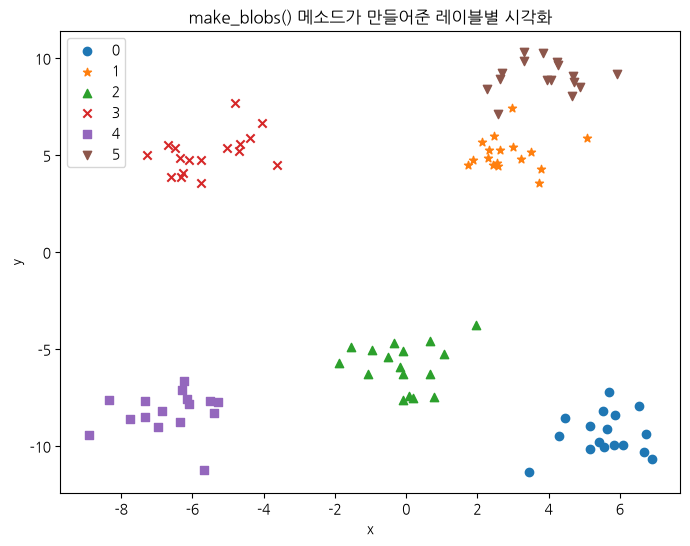

In [9]:
plt.figure(figsize=[8, 6])
markers = ['o', '*', '^', 'x', 's', 'v']

for index, marker in enumerate(markers):
    df_index = df[df.label == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('make_blobs() 메소드가 만들어준 레이블별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

가우시안 혼합 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화

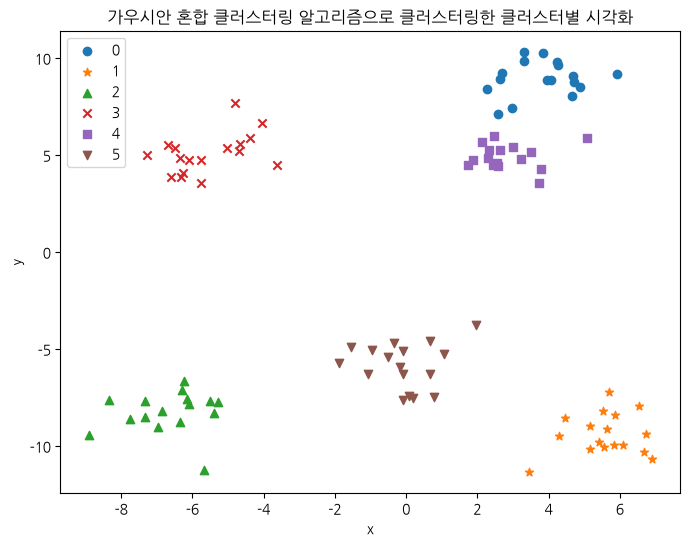

In [10]:
plt.figure(figsize=[8, 6])
markers = ['o', '*', '^', 'x', 's', 'v']

for index, marker in enumerate(markers):
    df_index = df[df.cluster == index]
    plt.scatter(x=df_index.x, y=df_index.y, marker=marker, label=index)

plt.title('가우시안 혼합 클러스터링 알고리즘으로 클러스터링한 클러스터별 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

학습된 모델을 평가한다.

In [12]:
# silhouette_score() 함수에 피쳐(x_train)와 군집화 결과로 얻은 클러스터(model.fit_predict(x_train))를 넘겨서 실루엣 스코에를 계산한다.
sil_score = silhouette_score(x_train, model.fit_predict(x_train))
print(sil_score)

0.700081972794829
